In [ ]:
from scipy.io import loadmat
import h5py
import scienceplots
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import scipy
from scipy import stats
from scipy.optimize import minimize_scalar
from scipy.stats import linregress
import tqdm
from tqdm import tqdm

In [ ]:
sync_time = loadmat('./data/sync.mat')['sync_time'][0]
sync_time_2 = loadmat('./data/sync.mat')['sync_time_2'][0]

In [ ]:
delta_time = loadmat('./data/delta_time.mat')['delta_time'][0]
delta_time_2 = loadmat('./data/delta_time.mat')['delta_time_2'][0]

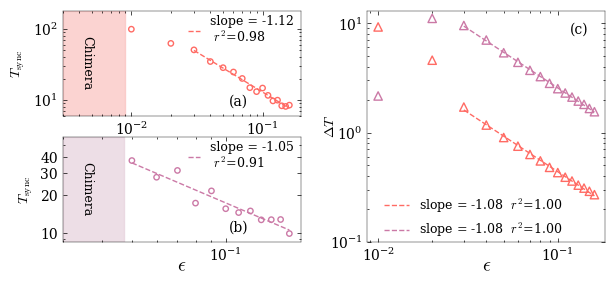

In [ ]:
filename = f'./data/weight.mat'
paras_combination = scipy.io.loadmat(filename)['weights']
custom_colors = ['#FF6B64', '#CF7878', '#CB79A6', '#FEB83E',  '#4493C8']
import matplotlib.ticker as mticker
with plt.style.context(['science', 'no-latex']):
    fig = plt.figure(figsize=(7, 3))
    gs_main = gridspec.GridSpec(1, 2, figure=fig, wspace=0.28)
    gs_top = gs_main[0, 0].subgridspec(2, 1, hspace=0.2)
    
    ax = fig.add_subplot(gs_top[0,0])
    x = paras_combination[:,2][~np.isnan(sync_time)]
    y= 0.01*np.array(sync_time)[~np.isnan(sync_time)]
    plt.scatter(x, y, facecolors='none', edgecolors = custom_colors[0], s= 15)
    
    logx = np.log(x[-14:])
    logy = np.log(y[-14:])
    slope, intercept, r_value, p_value, std_err = linregress(logx, logy)
    y_fit = np.exp(intercept + slope * logx)
    ax.plot(x[-14:], y_fit, linestyle='--',color = custom_colors[0], label = f"slope = {slope:.2f} \n $r^2$={r_value**2:.2f}")

    ax.axvspan(0.003, paras_combination[:,2][~np.isnan(sync_time)][0]-0.001, color='#fac1be', alpha=0.7)

    ax.set_ylim([6,180])
    ax.set_yscale('log')
    ax.set_xscale('log')
    # ax.set_xlabel(r'$\epsilon$', fontsize=12)
    ax.set_ylabel(r'$T_{\text{sync}}$', fontsize=10)
    ax.set_xlim(left=0.003)
    ax.legend(fontsize=9,handlelength=1.0, loc='upper right', bbox_to_anchor=(1.01, 1.01), borderaxespad=0.)
    ax.text(0.1,0.5, 'Chimera', transform=ax.transAxes, fontsize=9,rotation =-90, ha="center", va="center")
    ax.text(0.7,0.1, '(a)', transform=ax.transAxes, fontsize=10)
    for spine in ax.spines.values():
        spine.set_linewidth(0.3)
            
    
    
    ax = fig.add_subplot(gs_top[1,0])
    x = paras_combination[:,2][~np.isnan(sync_time_2)]
    y= 0.01*np.array(sync_time_2)[~np.isnan(sync_time_2)]
    plt.scatter(x, y, facecolors='none', edgecolors = custom_colors[2], s= 15)
    
    logx = np.log(x[-13:])
    logy = np.log(y[-13:])
    slope, intercept, r_value, p_value, std_err = linregress(logx, logy)
    y_fit = np.exp(intercept + slope * logx)
    ax.plot(x[-13:], y_fit, linestyle='--',color = custom_colors[2], label = f"slope = {slope:.2f} \n $r^2$={r_value**2:.2f}")

    ax.axvspan(0.03, paras_combination[:,2][~np.isnan(sync_time_2)][0]-0.003, color='#e6d1dc', alpha=0.7)

    ax.set_ylim(top = 58)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlabel(r'$\epsilon$', fontsize=14, labelpad=-5)
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ticks  = [10, 20, 30, 40]
    labels = ['10', '20', '30', '40']   
    ax.set_yticks(ticks)
    ax.set_yticklabels(labels)
    ax.set_ylabel(r'$T_{\text{sync}}$', fontsize=10)
    ax.set_xlim(left=0.03)
    ax.legend(fontsize=9,handlelength=1.0, loc='upper right', bbox_to_anchor=(1.01, 1.01), borderaxespad=0.)
    ax.text(0.1,0.5, 'Chimera', transform=ax.transAxes, fontsize=9,rotation = -90, ha="center", va="center")
    ax.text(0.7,0.1, '(b)', transform=ax.transAxes, fontsize=10)
    for spine in ax.spines.values():
        spine.set_linewidth(0.3)


            

    ax = fig.add_subplot(gs_main[0, 1])
    x = paras_combination[:,2][~np.isnan(delta_time)]
    y= 0.01*np.array(delta_time)[~np.isnan(delta_time)]
    ax.scatter(x, y,marker='^', facecolors='none',color = custom_colors[0])
    
    logx = np.log(x[-14:])
    logy = np.log(y[-14:])
    slope, intercept, r_value, p_value, std_err = linregress(logx, logy)
    y_fit = np.exp(intercept + slope * logx)
    ax.plot(x[-14:], y_fit,color = custom_colors[0], linestyle='--', label = f"slope = {slope:.2f}  $r^2$={r_value**2:.2f}")

    x = paras_combination[:,2][~np.isnan(delta_time_2)]
    y= 0.01*np.array(delta_time_2)[~np.isnan(delta_time_2)]
    ax.scatter(x, y, marker='^', facecolors='none', edgecolors=custom_colors[2])
    
    logx = np.log(x[-14:])
    logy = np.log(y[-14:])
    slope, intercept, r_value, p_value, std_err = linregress(logx, logy)
    y_fit = np.exp(intercept + slope * logx)
    ax.plot(x[-14:], y_fit, linestyle='--', label = f"slope = {slope:.2f}  $r^2$={r_value**2:.2f}", color = custom_colors[2])
    
    ax.set_ylim([0.1,13])
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlabel(r'$\epsilon$', fontsize=14, labelpad=-5)
    ax.set_ylabel(r'$\Delta T$', fontsize=10, labelpad = -5)
    ax.legend(fontsize=9, loc='lower left', bbox_to_anchor=(0.05, -0.01), borderaxespad=0.)
    ax.text(0.85,0.9, '(c)', transform=ax.transAxes, fontsize=10)

    for spine in ax.spines.values():
        spine.set_linewidth(0.3)
plt.show()